# COVID-19 Exploratory Data Analysis

### What is Exploratory Data Analysis (EDA)?

Exploratory Data Analysis (EDA) is the process of looking at and
visualizing a dataset to understand its structure, patterns, and
relationships before doing any deeper analysis or modeling. In this
project, we use summary statistics, charts, and plots to find trends,
spot unusual values, and understand what the data is telling us.

### About the Dataset — owid-covid-data

This dataset is collected by Our World in Data (OWID) and contains
COVID-19 statistics for countries around the world. Each row is a
snapshot of one country on one date, and includes information such as
new and total cases, new and total deaths, testing, vaccination
numbers, and country details like population, median age, and GDP
per capita.

#### Introduction

The goal of this project is to explore how COVID-19 spread and
affected different parts of the world over time. We will clean the
data, look at cases and deaths across continents, study vaccination
progress, find unusual values, create new useful columns, and see how
things changed over time. This will help us understand the overall
pattern of the pandemic using only NumPy, Pandas, Matplotlib, and
Seaborn.

#### Import the necessary libraries

In [2]:
# remove warning messages
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Import dataset

In [5]:
df = pd.read_csv("C:\data science\Data Sett\owid-covid-data.csv")

#### Display the first 5 rows of the dataset

In [6]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


#### Display the last 5 rows of the dataset

In [7]:
df.tail()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429434,ZWE,Africa,Zimbabwe,2024-08-04,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN


#### Data cleaning

In [10]:
print(df.shape)
pd.set_option('display.max_columns', None)
print(df.isna().sum())

(429435, 59)
iso_code                                           0
continent                                      26525
location                                           0
date                                               0
total_cases                                        0
new_cases                                          0
new_cases_smoothed                             20506
total_deaths                                       0
new_deaths                                         0
new_deaths_smoothed                            20057
total_cases_per_million                        17631
new_cases_per_million                          19276
new_cases_smoothed_per_million                 20506
total_deaths_per_million                       17631
new_deaths_per_million                         18827
new_deaths_smoothed_per_million                20057
reproduction_rate                             244618
total_tests                                   350048
new_tests                        

If a column has too many missing values (like more than 50-60%), it's often better to drop the whole column — trying to fill it would just be guessing.

If a column has only some missing values and is important, we can fill it in (for example, with the average, or with 0 if "no data" logically means zero).

If a row is missing something critical (like the date or location), we might drop that row.

Columns like total_cases, new_cases, total_deaths, new_deaths → missing usually means no cases reported that day, so we fill with 0.

Columns like icu_patients, hosp_patients, weekly_icu_admissions → these have too many missing values and aren't needed for our plan, so we can drop them.

Country info columns like population, median_age, gdp_per_capita → these stay the same for a country across all dates, so we can fill missing values using the country's own known value.

In [51]:
# Fill case/death columns with 0 (no cases reported)
cols_fill_zero = ['total_cases','new_cases', 'total_deaths', 'new_deaths']
df[cols_fill_zero] = df[cols_fill_zero].fillna(0)

# Drop columns with too many missing values
cols_to_drop = ['icu_patients', 'icu_patients_per_million', 'hosp_patients',
                 'hosp_patients_per_million', 'weekly_icu_admissions',
                 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
                 'weekly_hosp_admissions_per_million']
df = df.drop(columns=cols_to_drop,errors='ignore')

# Fill country-level info using each country's own known value
country_cols = ['population', 'median_age', 'gdp_per_capita', 'population_density',
                 'life_expectancy', 'human_development_index']
df[country_cols] = df.groupby('location')[country_cols].transform(lambda x: x.fillna(x.mean()))

The date column is loaded as plain text right now, but it should be treated as an actual date, so we can sort it and plot it over time properly.

Column names should be clean — no extra spaces, all lowercase (yours already look clean, but we check anyway, just like your demo did).

We also check for and remove any duplicate rows (exact copies), which can mess up analysis.

In [22]:
# Fix column names (lowercase, no spaces)
df.columns = df.columns.str.strip().str.lower()

# Convert date column from text to actual date type
df['date'] = pd.to_datetime(df['date'])

# Check and remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


#### Data understanding

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 429435 entries, 0 to 429434
Data columns (total 59 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    429435 non-null  object        
 1   continent                                   402910 non-null  object        
 2   location                                    429435 non-null  object        
 3   date                                        429435 non-null  datetime64[ns]
 4   total_cases                                 429435 non-null  float64       
 5   new_cases                                   429435 non-null  float64       
 6   new_cases_smoothed                          408929 non-null  float64       
 7   total_deaths                                429435 non-null  float64       
 8   new_deaths                                  429435 non-null  float64      

In [29]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,reproduction_rate,total_tests,new_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,positive_rate,tests_per_case,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,new_vaccinations_smoothed,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,new_vaccinations_smoothed_per_million,new_people_vaccinated_smoothed,new_people_vaccinated_smoothed_per_hundred,stringency_index,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,4.294350e+05,4.294350e+05,4.089290e+05,4.294350e+05,429435.000000,409378.000000,411804.000000,410159.000000,408929.000000,411804.000000,410608.000000,409378.000000,184817.000000,7.938700e+04,7.540300e+04,79387.000000,75403.000000,1.039650e+05,103965.000000,95927.000000,9.434800e+04,8.541700e+04,8.113200e+04,7.806100e+04,5.360000e+04,7.097100e+04,1.950290e+05,85417.000000,81132.000000,78061.000000,53600.000000,195029.000000,1.921770e+05,192177.000000,196190.000000,360492.000000,334663.000000,323270.000000,331315.000000,328292.000000,211996.000000,328865.000000,345911.000000,247165.000000,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,7.062901e+06,7.657486e+03,8.041026e+03,7.792336e+04,68.702046,72.060828,112096.199420,122.357073,122.713852,835.514337,0.762321,0.764530,0.911495,2.110457e+07,6.728541e+04,924.254752,3.272461,1.421784e+05,2.826364,0.098079,2.403633e+03,5.616980e+08,2.487064e+08,2.286639e+08,1.505811e+08,7.398640e+05,2.838758e+05,124.279558,53.501409,48.680182,36.301489,1851.477596,1.060707e+05,0.074678,42.877560,394.072932,30.456296,8.683893,5.486494,18904.182972,13.924729,264.639534,8.556055,10.772438,33.097758,50.649390,3.106895,73.702098,0.722178,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666404
std,4.387137e+07,2.244573e+05,8.661611e+04,4.323391e+05,1338.073082,513.636565,162240.412405,1508.778585,559.701663,1134.932641,6.982532,2.546543,0.399925,8.409869e+07,2.477340e+05,2195.428490,9.033826,1.138215e+06,7.308225,0.116097,3.344366e+04,1.842160e+09,8.006461e+08,7.403763e+08,4.360697e+08,3.183064e+06,1.922352e+06,85.098042,29.379655,29.042282,30.218208,3117.828731,7.866884e+05,0.176364,24.870492,1785.451281,9.093554,6.093037,4.136260,19829.577836,20.073912,120.756698,4.934656,10.761091,13.853952,31.905236,2.549168,7.387914,0.149237,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892770
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.070000,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.140000,15.100000,1.140000,0.530000,661.240000,0.100000,79.370000,0.990000,0.100000,7.700000,1.190000,0.100000,53.280000,0.390000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.450000
25%,3.849000e+03,0.000000e+00,0.000000e+00,2.600000e+01,0.000000,0.000000,1916.100000,0.000000,0.000000,24.570000,0.000000,0.000000,0.720000,3.646540e+05,2.244000e+03,43.585000,0.290000,1.486000e+03,0.200000,0.020000,7.100000e+00,1.970788e+06,1.050009e+06,9.644000e+05,6.022820e+05,2.010000e+03,2.790000e+02,44.770000,27.

#### Analysis questions

**Q1: Which continent has the highest total cases?**

In [33]:
df.groupby('continent')['total_cases'].max().sort_values(ascending=False)

continent
North America    103436829.0
Asia              99373219.0
Europe            38997490.0
South America     37511921.0
Oceania           11861161.0
Africa             4072765.0
Name: total_cases, dtype: float64

**Q2: What is the average total vaccinations per continent?**

In [38]:
df.groupby('continent')['total_vaccinations'].mean().sort_values(ascending=False)

continent
Asia             2.461425e+08
South America    6.596235e+07
North America    6.520149e+07
Europe           2.695280e+07
Oceania          1.265038e+07
Africa           8.013434e+06
Name: total_vaccinations, dtype: float64

**Q3: How did total cases change over time, worldwide?**

In [54]:
world_trend = df.groupby('date')['new_cases'].sum()
world_trend.tail(5)

date
2024-08-10    0.0
2024-08-11    0.0
2024-08-12    0.0
2024-08-13    0.0
2024-08-14    0.0
Name: new_cases, dtype: float64

**Q4: Which country has the highest total deaths?**


In [65]:
df.groupby('location')['total_deaths'].max().sort_values(ascending=False).head(10)

location
World                            7057132.0
High-income countries            2997359.0
Upper-middle-income countries    2824452.0
Europe                           2102483.0
North America                    1671178.0
Asia                             1637249.0
South America                    1354187.0
European Union (27)              1262988.0
United States                    1193165.0
Lower-middle-income countries    1188026.0
Name: total_deaths, dtype: float64

**Q5: Which continent has the highest average vaccination rate?**

In [66]:
df.groupby('continent')['vaccination_rate'].mean().sort_values(ascending=False)

continent
South America    145.835556
Europe           136.021579
Oceania          128.093380
North America    125.279218
Asia             124.555192
Africa            30.084885
Name: vaccination_rate, dtype: float64

**Q6: How many countries are in each continent?**

In [67]:
df.groupby('continent')['location'].nunique().sort_values(ascending=False)

continent
Africa           58
Europe           55
Asia             51
North America    41
Oceania          24
South America    14
Name: location, dtype: int64

**Q7: What is the average death rate worldwide?**

In [68]:
df['death_rate'].mean()

10.935960773450406

**Q8: Which country has the highest total cases per million people?**

In [69]:
df.groupby('location')['total_cases_per_million'].max().sort_values(ascending=False).head(10)

location
Brunei           763598.60
San Marino       741418.25
Austria          671004.90
South Korea      667636.06
Martinique       659169.44
Jersey           641502.30
Faroe Islands    641351.60
Slovenia         641340.20
France           606706.00
Luxembourg       602376.20
Name: total_cases_per_million, dtype: float64

**Q9: What is the average GDP per capita among the top 10 countries by total cases?**

In [71]:
top10 = df.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10)
df[df['location'].isin(top10.index)]['gdp_per_capita'].mean()

28308.889801271853

**Q10: How many unique dates are covered in this dataset?**

In [72]:
df['date'].nunique()

1688

#### Visualizations

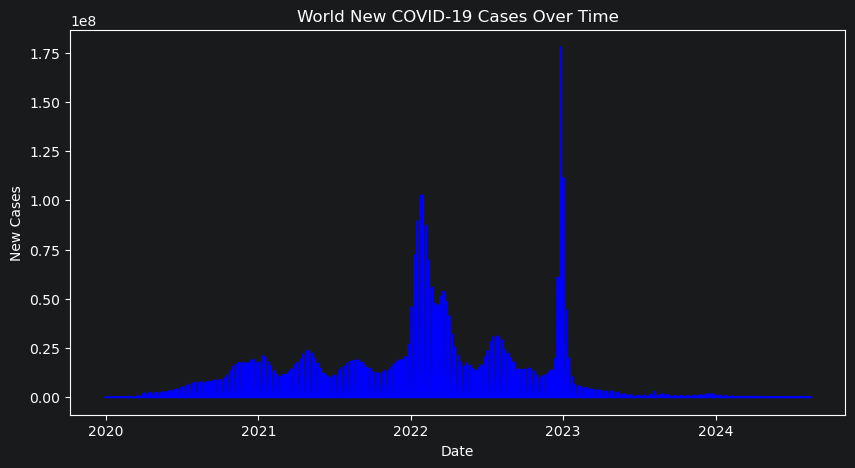

In [53]:
plt.figure(figsize=(10,5))
plt.plot(world_trend.index, world_trend.values, color='blue')
plt.title('World New COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.show()

**Chart 2: Total cases by continent**

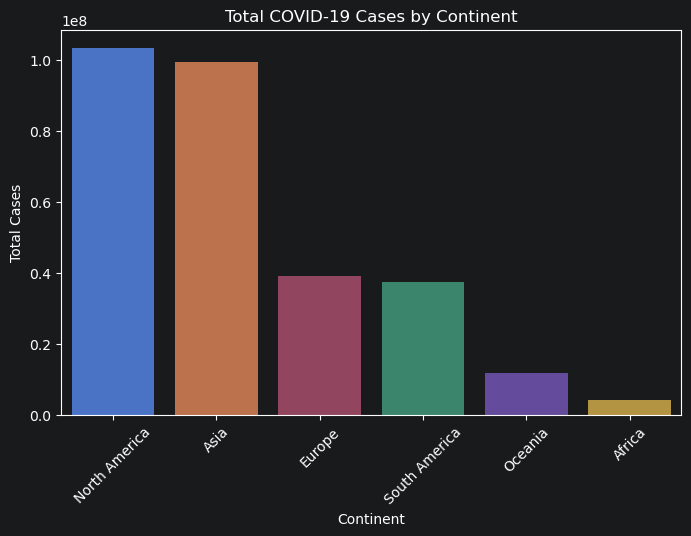

In [55]:
continent_cases = df.groupby('continent')['total_cases'].max().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=continent_cases.index, y=continent_cases.values)
plt.title('Total COVID-19 Cases by Continent')
plt.xlabel('Continent')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.show()

**Chart 3: Correlation between key numeric columns**

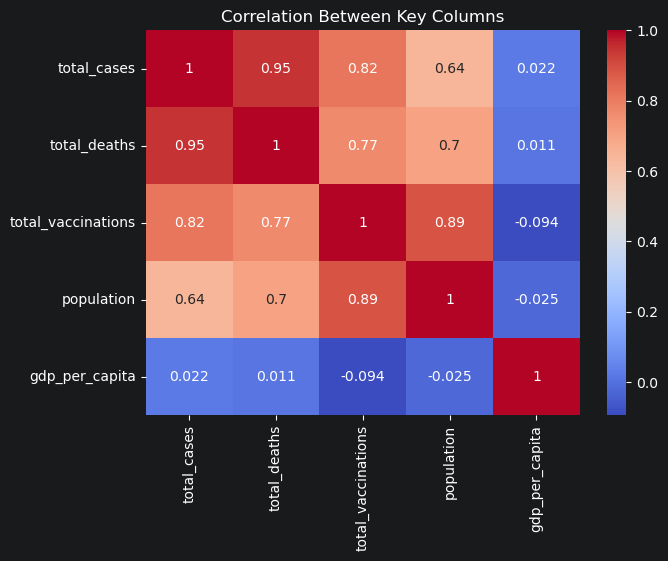

In [56]:
key_cols = ['total_cases', 'total_deaths', 'total_vaccinations', 'population', 'gdp_per_capita']
corr = df[key_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Key Columns')
plt.show()

**Chart 4: Top 10 countries by total cases**

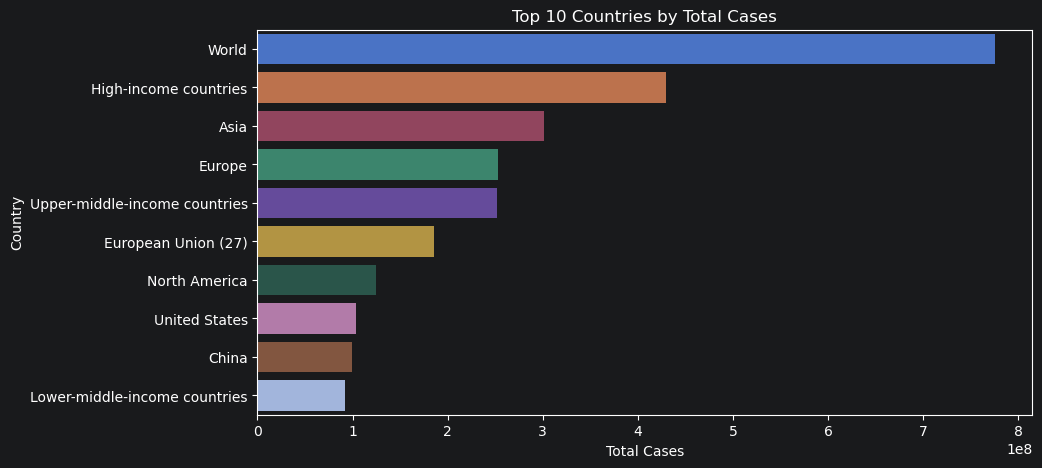

In [73]:
top10_cases = df.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10_cases.values, y=top10_cases.index)
plt.title('Top 10 Countries by Total Cases')
plt.xlabel('Total Cases')
plt.ylabel('Country')
plt.show()

**Chart 5: Distribution of death rate across countries**

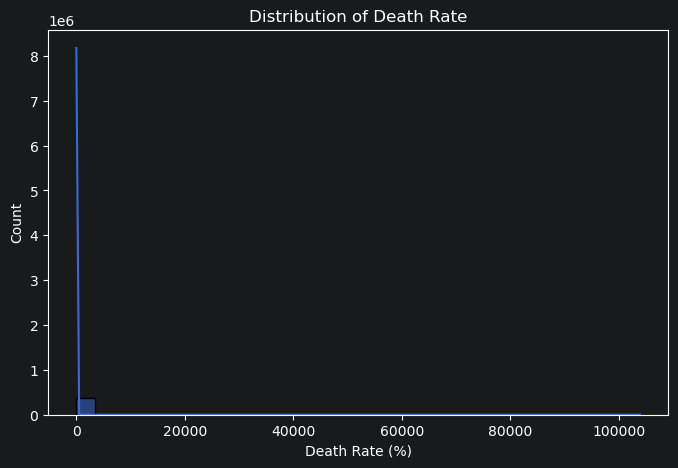

In [74]:
plt.figure(figsize=(8,5))
sns.histplot(df['death_rate'].dropna(), bins=30, kde=True)
plt.title('Distribution of Death Rate')
plt.xlabel('Death Rate (%)')
plt.show()

**Chart 6: Vaccination rate by continent**

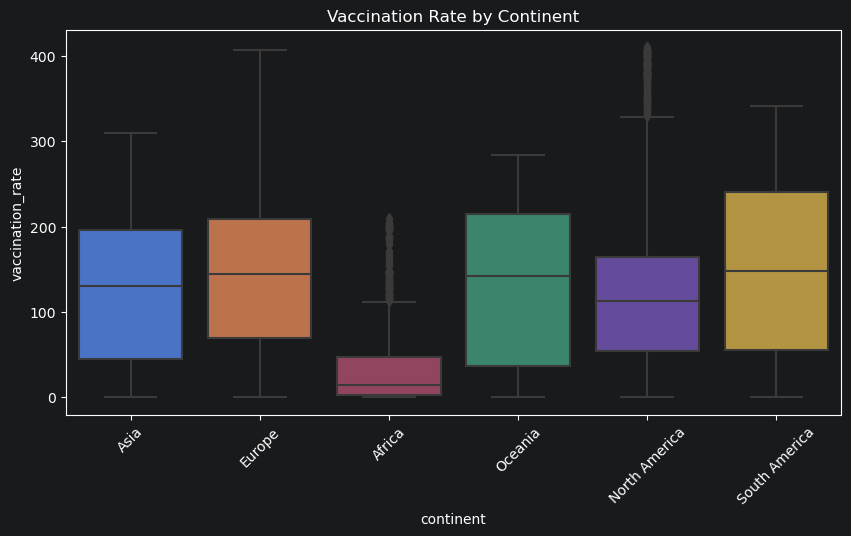

In [75]:
plt.figure(figsize=(10,5))
sns.boxplot(x='continent', y='vaccination_rate', data=df)
plt.title('Vaccination Rate by Continent')
plt.xticks(rotation=45)
plt.show()

**Chart 7: New cases vs new deaths**

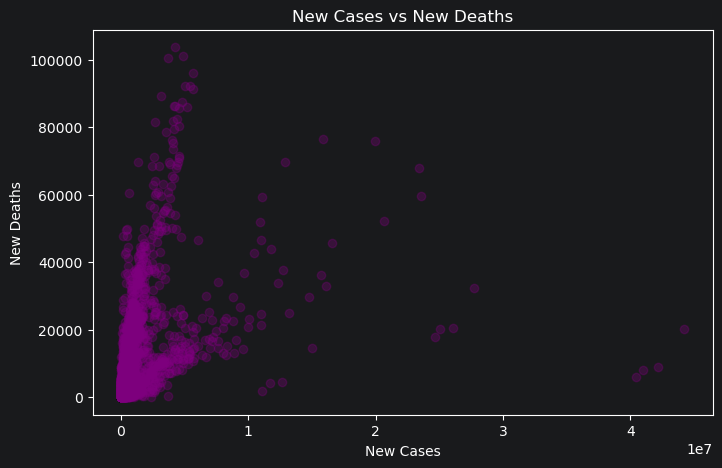

In [76]:
plt.figure(figsize=(8,5))
plt.scatter(df['new_cases'], df['new_deaths'], alpha=0.3, color='purple')
plt.title('New Cases vs New Deaths')
plt.xlabel('New Cases')
plt.ylabel('New Deaths')
plt.show()

**Chart 8: Total cases over time for top 5 countries**

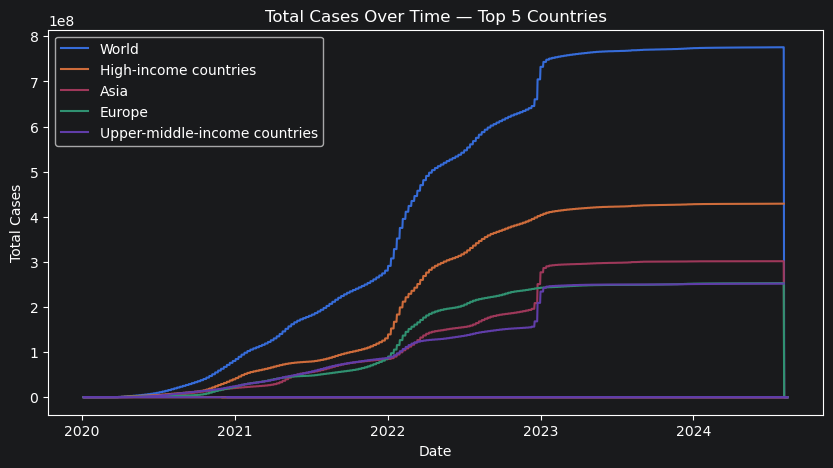

In [77]:
top5 = df.groupby('location')['total_cases'].max().sort_values(ascending=False).head(5).index

plt.figure(figsize=(10,5))
for country in top5:
    country_data = df[df['location'] == country]
    plt.plot(country_data['date'], country_data['total_cases'], label=country)

plt.title('Total Cases Over Time — Top 5 Countries')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.show()

**Chart 9: Population vs total cases**

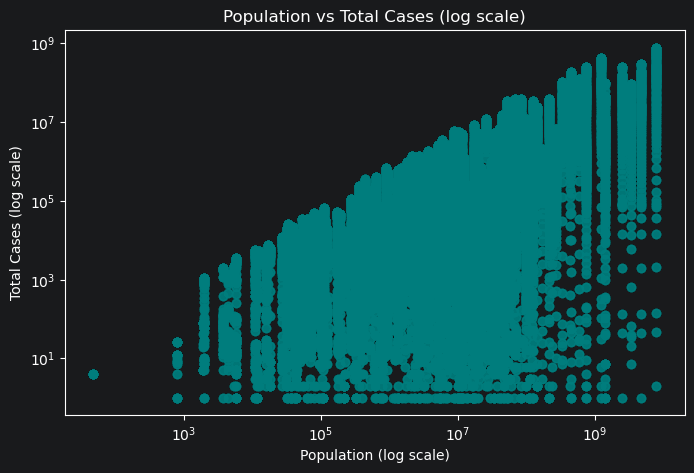

In [78]:
plt.figure(figsize=(8,5))
plt.scatter(df['population'], df['total_cases'], alpha=0.3, color='teal')
plt.xscale('log')
plt.yscale('log')
plt.title('Population vs Total Cases (log scale)')
plt.xlabel('Population (log scale)')
plt.ylabel('Total Cases (log scale)')
plt.show()

**Chart 10: Pairplot of key columns**

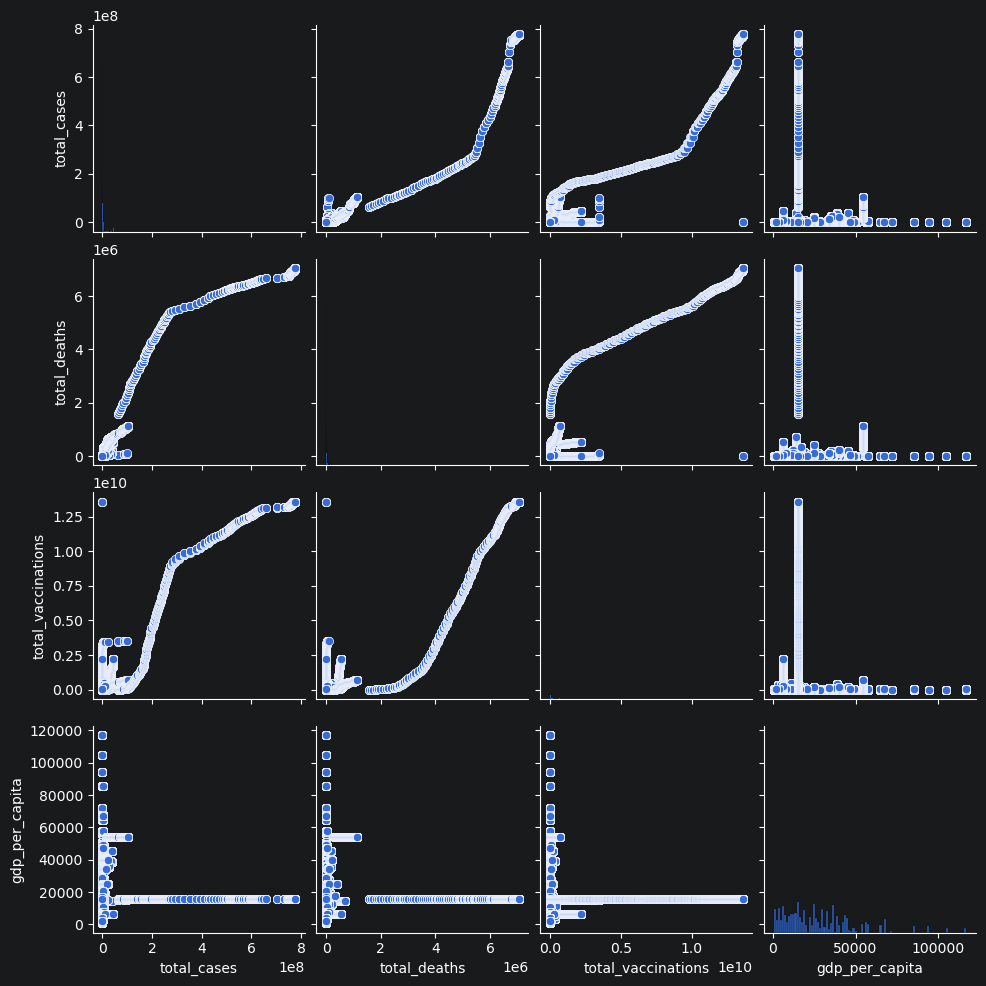

In [79]:
key_cols = ['total_cases', 'total_deaths', 'total_vaccinations', 'gdp_per_capita']
sns.pairplot(df[key_cols].dropna())
plt.show()

#### Outlier detection

**Boxplot to spot outliers in total cases**

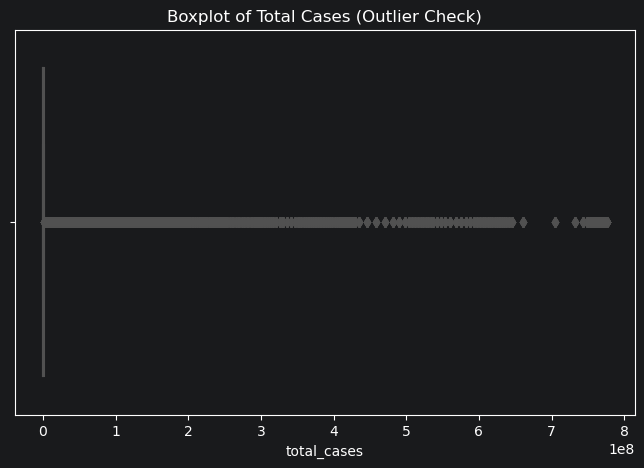

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['total_cases'])
plt.title('Boxplot of Total Cases (Outlier Check)')
plt.show()

In [58]:
Q1 = df['total_cases'].quantile(0.25)
Q3 = df['total_cases'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['total_cases'] < lower_limit) | (df['total_cases'] > upper_limit)]
print("Number of outlier rows:", outliers.shape[0])

Number of outlier rows: 71000


#### Feature engineering

**Create death rate column**

In [60]:
df['death_rate'] = (df['total_deaths'] / df['total_cases'].replace(0, np.nan)) * 100

**Create vaccination rate column**

In [61]:
df['vaccination_rate'] = (df['total_vaccinations'] / df['population']) * 100

**Extract year and month from date**

In [62]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

#### Time series plots

**World new deaths over time**

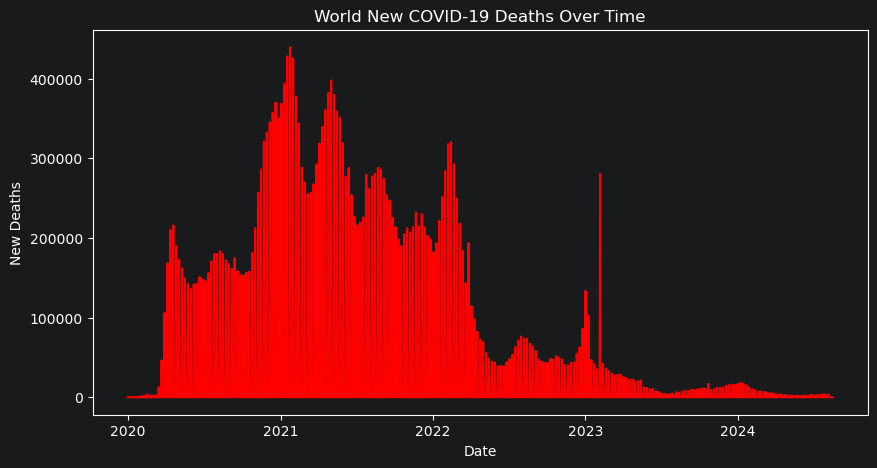

In [63]:
world_deaths = df.groupby('date')['new_deaths'].sum()

plt.figure(figsize=(10,5))
plt.plot(world_deaths.index, world_deaths.values, color='red')
plt.title('World New COVID-19 Deaths Over Time')
plt.xlabel('Date')
plt.ylabel('New Deaths')
plt.show()

**World total vaccinations over time**

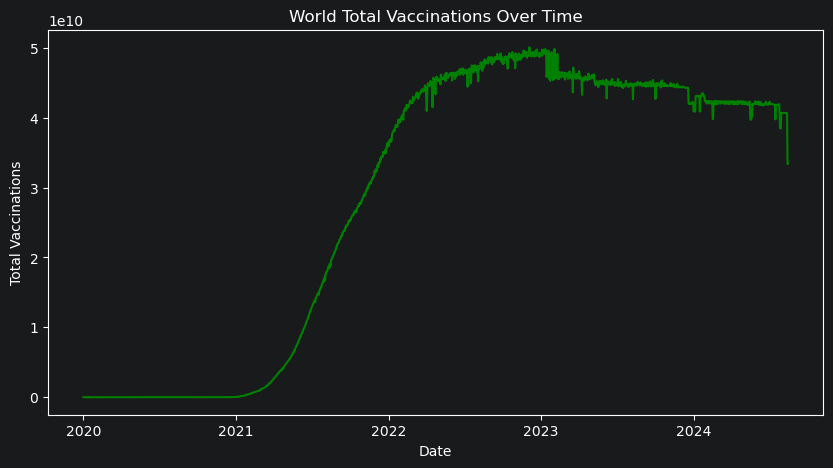

In [64]:
world_vaccinations = df.groupby('date')['total_vaccinations'].sum()

plt.figure(figsize=(10,5))
plt.plot(world_vaccinations.index, world_vaccinations.values, color='green')
plt.title('World Total Vaccinations Over Time')
plt.xlabel('Date')
plt.ylabel('Total Vaccinations')
plt.show()

#### Suggestions and recommendations

### Conclusions

- COVID-19 cases and deaths were not spread evenly across the world —
  some continents had far higher total cases than others.
- Vaccination totals increased steadily over time as more countries
  rolled out vaccine programs, while new case numbers rose and fell
  in waves.
- A number of countries showed very high total case counts compared
  to the rest of the data. These were treated as real extreme values
  (large countries with big populations), not data errors.
- The new "death_rate" and "vaccination_rate" columns give a fairer
  way to compare countries of different sizes, instead of only
  looking at raw totals.
- Missing data was common in fields like ICU admissions and hospital
  patients, since not every country reported every value — this is
  an important limitation to keep in mind when interpreting the results.

### Possible next steps

- Compare death rate and vaccination rate across continents.
- Look at specific countries in more detail instead of only world/continent totals.
- Study whether higher vaccination rates lined up with lower death rates.